Hey Ivette and Julia! As we discussed, I specifically loaded the bank-full.csv file and took the following steps for cleaning:


*   Checked for NA values (there were none to remove)
*   Converted all categorical variables to numeric
*   Defined X_bank_full and y_bank_full as features and target subsets of the bank_full dataframe

I figured for each algorithm I would let each of us do our own training and test set split, unless there's a good reason for us to use the same split. Let me know if I can answer any questions!

-Emmet

In [69]:
# From: https://archive.ics.uci.edu/dataset/222/bank+marketing
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [74]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [75]:
import pandas as pd

In [76]:
bank_full = pd.read_csv('bank-full.csv', sep = ';')
print(bank_full.head())

FileNotFoundError: [Errno 2] No such file or directory: 'bank-full.csv'

In [73]:
# Count NA/NULL values in each column (code from: https://www.geeksforgeeks.org/how-to-count-the-number-of-nan-values-in-pandas/)
column_nan_count = bank_full.isna().sum()
print("NaN count per column:")
print(column_nan_count)

# Appears to be no NA/NULL values in bank_full

NaN count per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [50]:
# Identify unique labels in categorical columns
for column in list(bank_full.columns):
  unique_values= bank_full[str(column)].unique()
  print('Unique values in ' + str(column) + ':' + str(unique_values))

Unique values in age:[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
Unique values in job:[ 5 10  3  2 12  6  1  8  7 11  4  9]
Unique values in marital:[2 1 3]
Unique values in education:[3 2 0 1]
Unique values in default:[0 1]
Unique values in balance:[ 2143    29     2 ...  8205 14204 16353]
Unique values in housing:[1 0]
Unique values in loan:[0 1]
Unique values in contact:[0 1 2]
Unique values in day:[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
Unique values in month:[ 5  6  7  8 10 11 12  1  2  3  4  9]
Unique values in duration:[ 261  151   76 ... 1298 1246 1556]
Unique values in campaign:[ 1  2  3  5  4  6  7  8  9 10 11 12 13 19 14 24 16 32 18 22 15 17 25 21
 43 51 63 41 26 28 55 50 38 23 20 29 31 37 30 46 27 58 33 35 34 36 39 44]
Unique valu

In [51]:
# Convert categorical variables with integers
bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
                          'management', 'retired', 'self-employed', 'services',
                          'student', 'technician', 'unemployed', 'unknown'],
                           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['marital'].replace(['single', 'married', 'divorced'],[1, 2, 3], inplace=True)
bank_full['education'].replace(['tertiary', 'secondary', 'unknown', 'primary'],[3, 2, 0, 1], inplace=True)
bank_full['default'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['housing'].replace(['yes', 'no'], [1, 0], inplace=True)
bank_full['loan'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['contact'].replace(['unknown', 'cellular', 'telephone'], [0, 1, 2], inplace=True)
bank_full['month'].replace(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['poutcome'].replace(['unknown', 'failure', 'other', 'success'], [2, 0, 3, 1], inplace=True)
bank_full['y'].replace(['no', 'yes'], [0, 1], inplace=True)

In [9]:
# Verifying that variable replacement worked
print(bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      5       261         1     -1         0         2  0  
1    5      5       151         1     -1         0         2  0  
2    5      5        76         1     -1         0         2  0  
3    5      5        92         1     -1         0         2  0  
4    5      5       198         1     -1         0         2  0  


In [52]:
# define features and targets dataframes
X_bank_full = bank_full.drop(columns=['y'])
y_bank_full = bank_full[['y']]

print(X_bank_full.head())
print(y_bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  
0    5      5       261         1     -1         0         2  
1    5      5       151         1     -1         0         2  
2    5      5        76         1     -1         0         2  
3    5      5        92         1     -1         0         2  
4    5      5       198         1     -1         0         2  
   y
0  0
1  0
2  0
3  0
4  0


In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, classification_report
import matplotlib.pyplot as plt

In [54]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_bank_full, y_bank_full, test_size=0.2, random_state=42)

In [55]:
# Define the Decision Tree model and parameter grid
param_grid = {'max_depth': range(1, 21)}
tree = DecisionTreeClassifier(random_state=42)

In [57]:
# Perform Grid Search with cross-validation (cv=5)
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train.values.ravel())

# Get the best max_depth
best_depth = grid_search.best_params_['max_depth']
best_depth

7

In [23]:
# Fit the Decision Tree model using the best max_depth
best_tree = DecisionTreeClassifier(random_state=42, max_depth=7)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [24]:
# Make predictions
y_pred = best_tree.predict(X_test)

In [40]:
# Evaluate performance
precision = precision_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(precision)

0.6016042780748663


In [37]:
print(class_report)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.60      0.41      0.49      1091

    accuracy                           0.90      9043
   macro avg       0.76      0.69      0.72      9043
weighted avg       0.88      0.90      0.89      9043



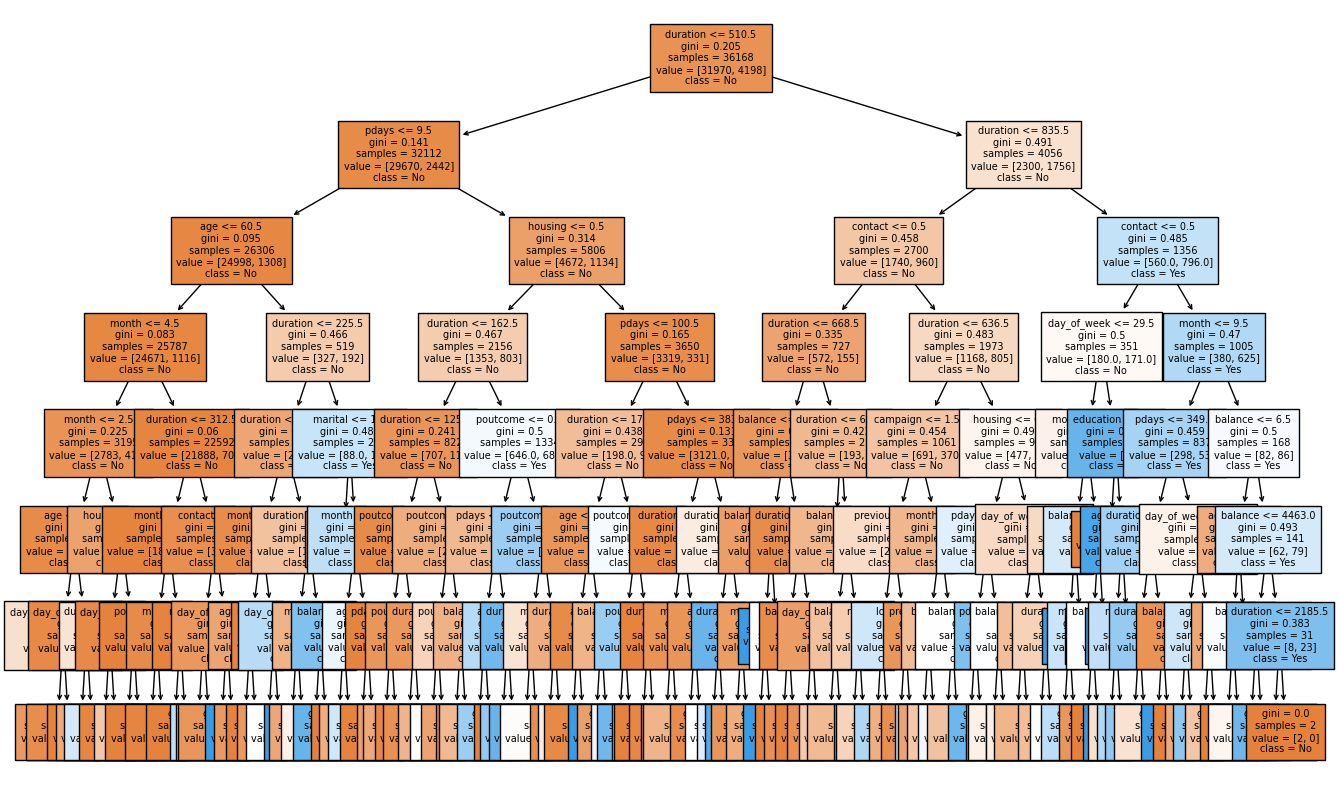

In [44]:
# Visualize the decision tree
plt.figure(figsize=(16, 10))
plot_tree(best_tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True, fontsize=7)
plt.show()

In [ ]:
# Display feature importance
feature_importance = pd.DataFrame({
    'Feature': best_tree.feature_names_in_,
    'Importance': best_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
11,duration,0.509750
6,housing,0.113662
13,pdays,0.107930
10,month,0.069296
15,poutcome,0.061380
0,age,0.053038
8,contact,0.029582
9,day,0.023557
5,balance,0.021013
2,marital,0.002839


In [60]:
# Re-select the features based on feature importance
X = bank_full[['duration', 'housing', 'pdays', 'month', 'poutcome', 'age']]
y = bank_full[['y']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Get the best max_depth
grid_search.fit(X_train, y_train.values.ravel())
best_depth = grid_search.best_params_['max_depth']
best_depth

6

In [ ]:
# Fit a new Decision Tree model
best_tree_2 = best_tree = DecisionTreeClassifier(random_state=42, max_depth=6)
best_tree_2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [ ]:
# Make prediction
y_pred = best_tree_2.predict(X_test)

# Evaluate performance
precision = precision_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(precision)

0.6


In [68]:
print(class_report)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.60      0.36      0.45      1091

    accuracy                           0.89      9043
   macro avg       0.76      0.66      0.69      9043
weighted avg       0.88      0.89      0.88      9043

